In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings

warnings.filterwarnings('ignore')

sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100

In [2]:
df = pd.read_csv('C:\\Users\\DELL\\OneDrive\\Desktop\\intern project\\cleaned_data_project1.csv')

df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,1/4/2023,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,8/23/2024,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2/27/2024,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,10/15/2023,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,5/8/2025,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


## Descriptive Statistics

In [4]:
print('DESCRIPTIVE STATISTICS FOR NUMERICAL COLUMNS')
df.describe().round(2)

DESCRIPTIVE STATISTICS FOR NUMERICAL COLUMNS


,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200.00,1200.00,1200.00,1200.00
mean,2.95,356.41,5.48,1053.97
std,1.41,197.18,2.28,819.86
min,1.00,11.39,1.00,11.39
25%,2.00,186.06,4.00,410.52
50%,3.00,364.21,5.00,823.62
75%,4.00,521.57,7.00,1578.48
max,5.00,699.93,10.00,3456.40


In [6]:
num_cols=df.select_dtypes(include='number').columns.tolist()

print(f'{'Column':<20}{'Mean':>12}{'Median':>12}{'Skew':>10}')
print('-'*56)
for col in num_cols:
    mean=df[col].mean()
    median=df[col].median()
    skew=df[col].skew()
    flag='(skewed)' if abs(skew)>1 else ''
    print(f'{col:<20}{mean:>12.2f}{median:>12.2f}{skew:>10.2f}{flag}')

Column                      Mean      Median      Skew
--------------------------------------------------------
Quantity                    2.95        3.00      0.03
UnitPrice                 356.41      364.21     -0.03
ItemsInCart                 5.49        5.00      0.00
TotalPrice               1053.97      823.62      0.89


## Distribution Analysis

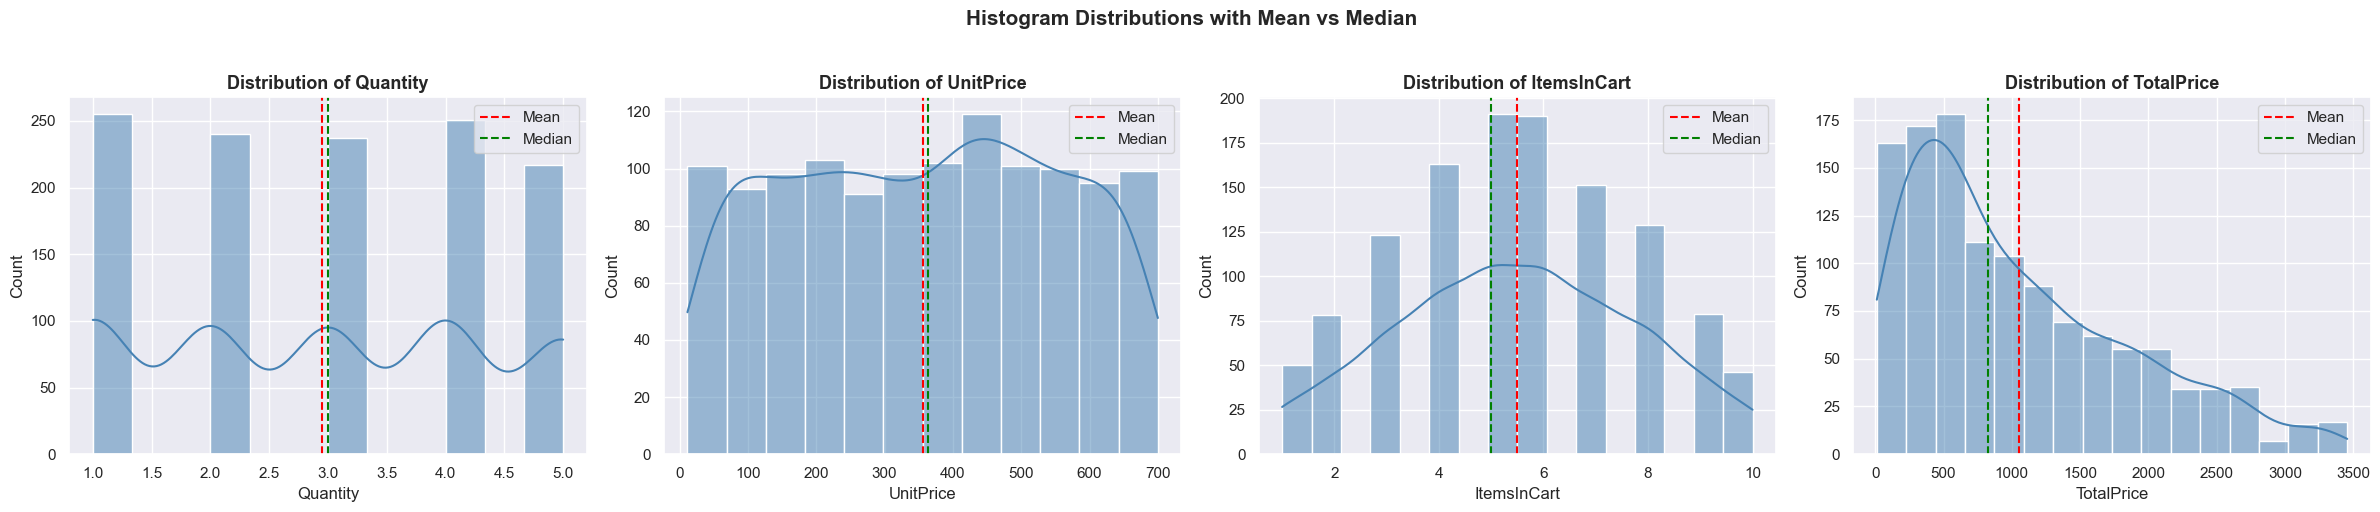

In [23]:
fig, axes = plt.subplots(1, len(num_cols), figsize=(6*len(num_cols),5))
if len(num_cols)==1:
    axes=[axes]

for ax,col in zip(axes,num_cols):
    sns.histplot(df[col],kde=True, ax=ax, color='steelblue',edgecolor='white')
    ax.axvline(df[col].mean(),color='red',linestyle='--',linewidth=1.5, label='Mean')
    ax.axvline(df[col].median(),color='green',linestyle='--',linewidth=1.5, label='Median')
    ax.set_title(f'Distribution of {col}',fontsize=13,fontweight='bold')
    ax.set_xlabel(col)
    ax.legend()

plt.suptitle('Histogram Distributions with Mean vs Median', fontsize=15,fontweight='bold',y=1.02)
plt.tight_layout()
plt.show()

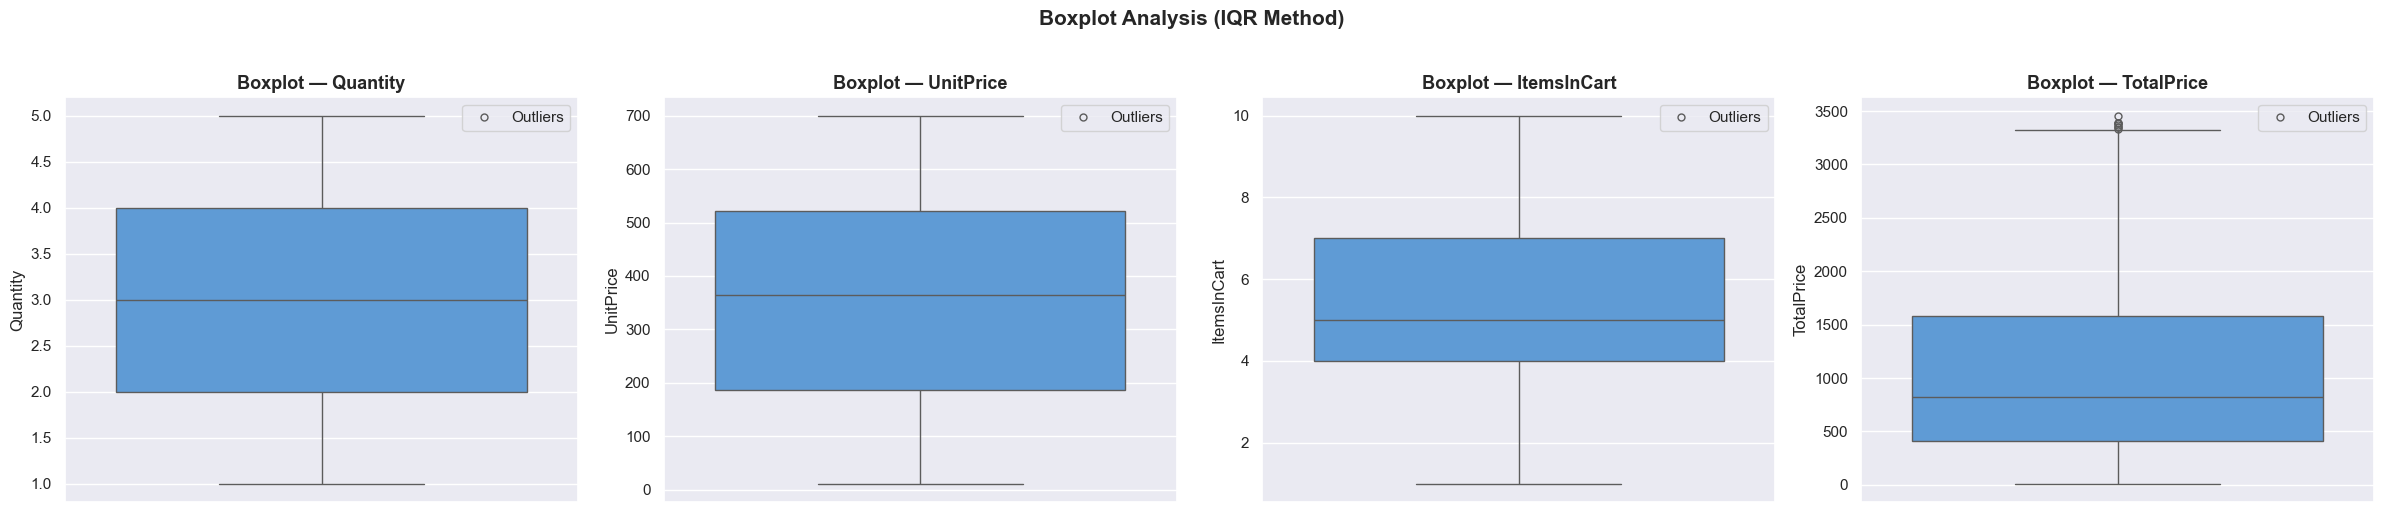

In [24]:
# Boxplots - The Fingerprint of Variability
fig, axes = plt.subplots(1, len(num_cols), figsize=(6 * len(num_cols), 5))
if len(num_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, num_cols):
    sns.boxplot(y=df[col], ax=ax, color='#4C9BE8', flierprops=dict(
        marker='o', color='red', markersize=5, label='Outliers'
    ))
    ax.set_title(f'Boxplot — {col}', fontsize=13, fontweight='bold')
    ax.set_ylabel(col)

plt.suptitle('Boxplot Analysis (IQR Method)', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [32]:
print('IQR OUTLIER DETECTION')

outlier_summary = []
for col in num_cols:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 *IQR
    upper = Q3 + 1.5 *IQR
    n_out = df[(df[col] < lower) | (df[col] > upper)].shape[0]
    outlier_summary.append({'Column': col, 'Q1': Q1, 'Q3': Q3,
                             'IQR': IQR, 'Lower Fence': lower,
                             'Upper Fence': upper, 'Outlier Count': n_out})
    print(f'{col}')
    print(f'Q1={Q1:.2f}  Q3={Q3:.2f}  IQR={IQR:.2f}')
    print(f'Fences: [{lower:.2f}, {upper:.2f}]')
    print(f'Outliers detected: {n_out}\n')

outlier_df = pd.DataFrame(outlier_summary).set_index('Column')

IQR OUTLIER DETECTION
Quantity
Q1=2.00  Q3=4.00  IQR=2.00
Fences: [-1.00, 7.00]
Outliers detected: 0

UnitPrice
Q1=186.06  Q3=521.57  IQR=335.51
Fences: [-317.20, 1024.83]
Outliers detected: 0

ItemsInCart
Q1=4.00  Q3=7.00  IQR=3.00
Fences: [-0.50, 11.50]
Outliers detected: 0

TotalPrice
Q1=410.52  Q3=1578.47  IQR=1167.95
Fences: [-1341.41, 3330.41]
Outliers detected: 8



## Trend & Pattern Analysis

In [28]:
# Parse Date and create time features
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['Month'] = df['Date'].dt.month
df['Month_Name'] = df['Date'].dt.strftime('%b')
df['Year'] = df['Date'].dt.year
df['DayOfWeek'] = df['Date'].dt.day_name()

print('Date features extracted')
df[['Date', 'Month', 'Month_Name', 'Year', 'DayOfWeek']].head()

Date features extracted


,Date,Month,Month_Name,Year,DayOfWeek
0,2023-01-04,1,Jan,2023,Wednesday
1,2024-08-23,8,Aug,2024,Friday
2,2024-02-27,2,Feb,2024,Tuesday
3,2023-10-15,10,Oct,2023,Sunday
4,2025-05-08,5,May,2025,Thursday


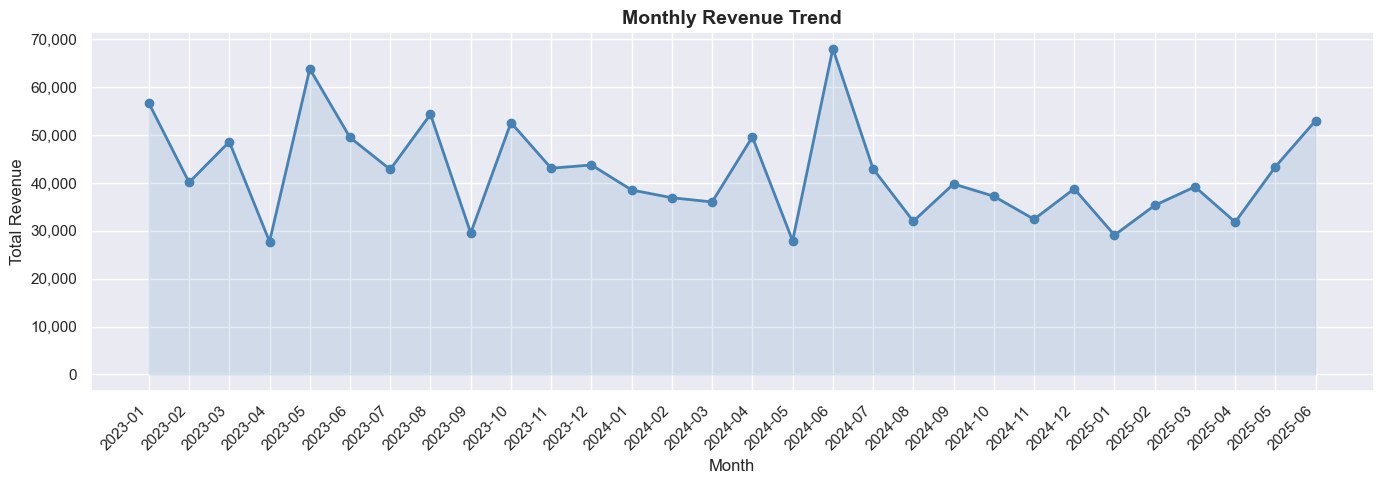

In [29]:
#Monthly revenue trend
monthly = df.groupby(['Year', 'Month'])['TotalPrice'].sum().reset_index()
monthly['Period'] = monthly['Year'].astype(str) + '-' + monthly['Month'].astype(str).str.zfill(2)
monthly = monthly.sort_values('Period')

plt.figure(figsize=(14, 5))
plt.plot(monthly['Period'], monthly['TotalPrice'], marker='o', color='steelblue', linewidth=2)
plt.fill_between(monthly['Period'], monthly['TotalPrice'], alpha=0.15, color='steelblue')
plt.xticks(rotation=45, ha='right')
plt.title('Monthly Revenue Trend', fontsize=14, fontweight='bold')
plt.ylabel('Total Revenue')
plt.xlabel('Month')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.show()

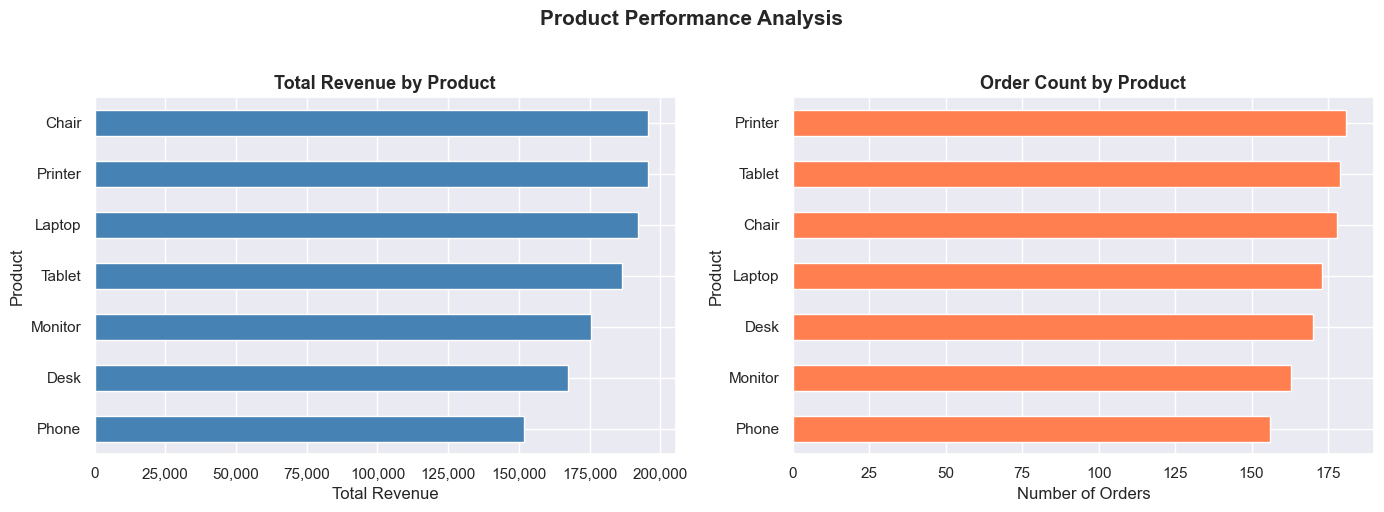

In [30]:
# Top products by revenue
product_rev = df.groupby('Product')['TotalPrice'].sum().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Revenue by product
product_rev.plot(kind='barh', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Total Revenue by Product', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Total Revenue')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
axes[0].invert_yaxis()

# Order count by product
product_count = df['Product'].value_counts()
product_count.plot(kind='barh', ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Order Count by Product', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Number of Orders')
axes[1].invert_yaxis()

plt.suptitle('Product Performance Analysis', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [31]:
# Referral source performance
ref_rev = df.groupby('ReferralSource')['TotalPrice'].agg(['sum', 'count', 'mean']).round(2)
ref_rev.columns = ['Total Revenue', 'Order Count', 'Avg Order Value']
ref_rev = ref_rev.sort_values('Total Revenue', ascending=False)
print('Referral Source Performance:')
print(ref_rev.to_string())

Referral Source Performance:
                Total Revenue  Order Count  Avg Order Value
ReferralSource                                             
Instagram           275285.45          259          1062.88
Email               261808.55          250          1047.23
Google              250441.48          241          1039.18
Facebook            250410.90          228          1098.29
Referral            226815.58          222          1021.69


## Correlation Analysis

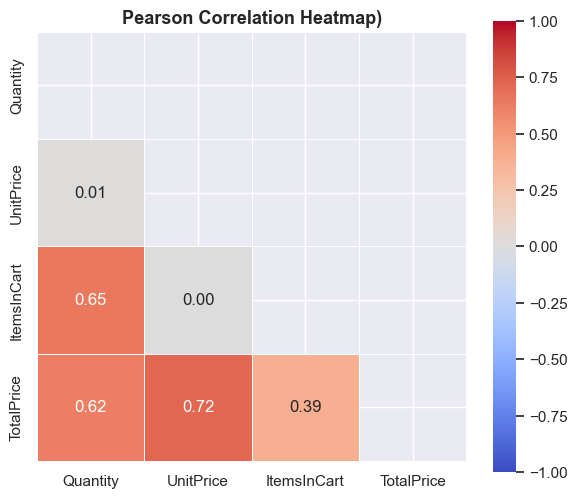

In [35]:
corr_matrix = df[num_cols].corr().round(2)

plt.figure(figsize=(6, 6))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, vmin=-1, vmax=1,
            linewidths=0.5, square=True, cbar_kws={'shrink': 0.8})
plt.title('Pearson Correlation Heatmap)',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


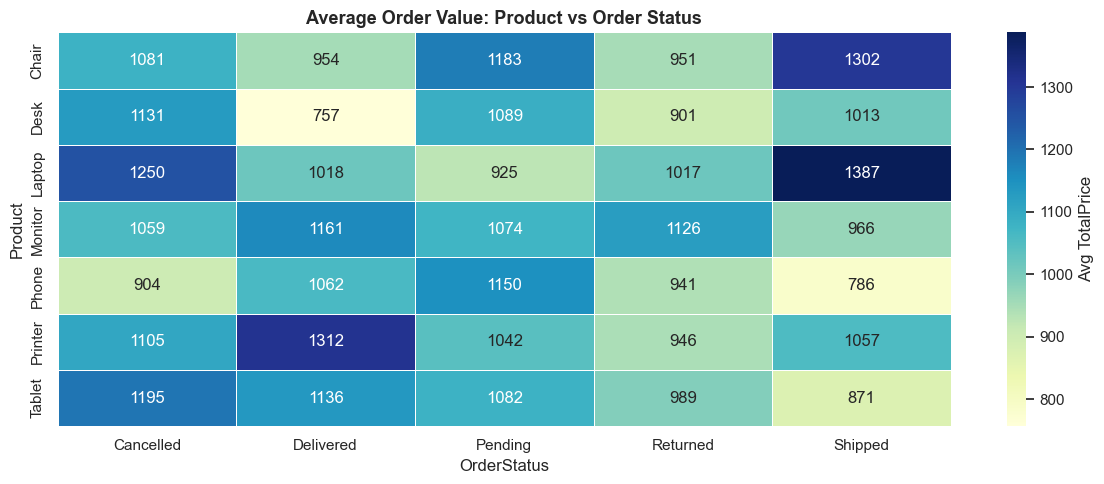

In [36]:
# Average order value by product and status
pivot = df.pivot_table(values='TotalPrice', index='Product',
                       columns='OrderStatus', aggfunc='mean').round(2)

plt.figure(figsize=(12, 5))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlGnBu',
            linewidths=0.5, cbar_kws={'label': 'Avg TotalPrice'})
plt.title('Average Order Value: Product vs Order Status', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()